===== BASIC INFO =====
<class 'pandas.DataFrame'>
RangeIndex: 424616 entries, 0 to 424615
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   timestamp            424616 non-null  datetime64[us]
 1   homeid               424616 non-null  int64         
 2   demand_kwh           424616 non-null  float64       
 3   solar_kwh            424616 non-null  float64       
 4   price_kwh            424616 non-null  float64       
 5   hour                 424616 non-null  int64         
 6   day_of_week          424616 non-null  int64         
 7   month                424616 non-null  int64         
 8   is_weekend           424616 non-null  int64         
 9   outdoor_temperature  423600 non-null  float64       
dtypes: datetime64[us](1), float64(4), int64(5)
memory usage: 32.4 MB
None

===== SUMMARY STATS =====
                        timestamp         homeid     demand_kwh  \
count       

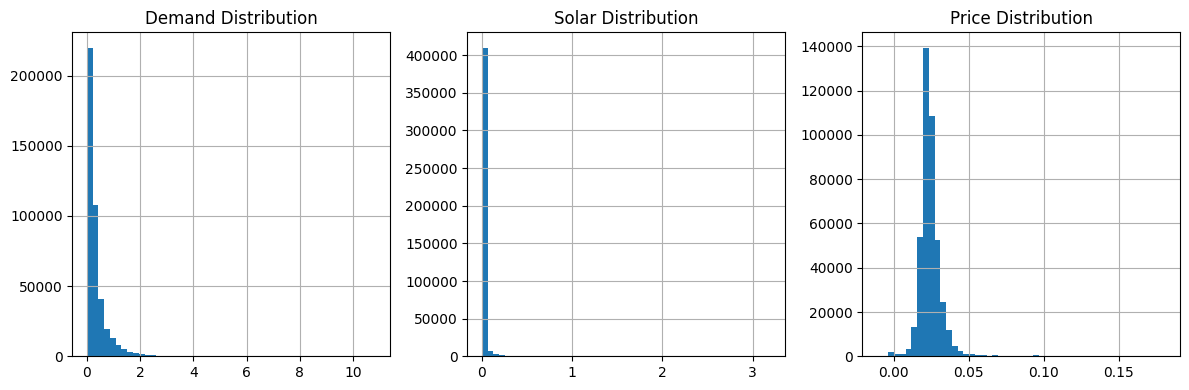

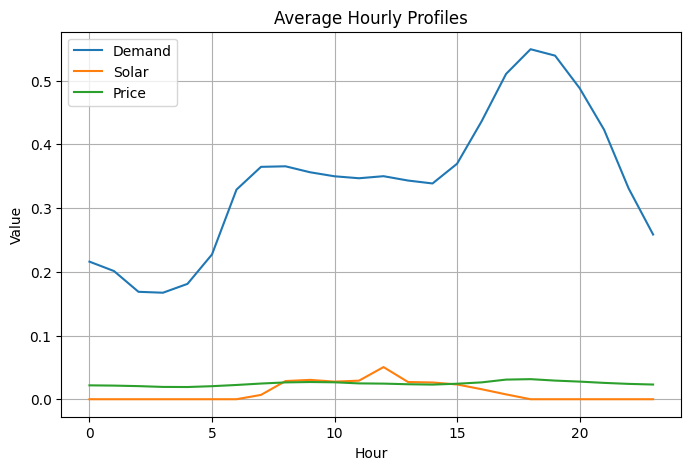


===== CORRELATION =====
            demand_kwh  solar_kwh  price_kwh
demand_kwh    1.000000  -0.011249   0.109921
solar_kwh    -0.011249   1.000000   0.011488
price_kwh     0.109921   0.011488   1.000000


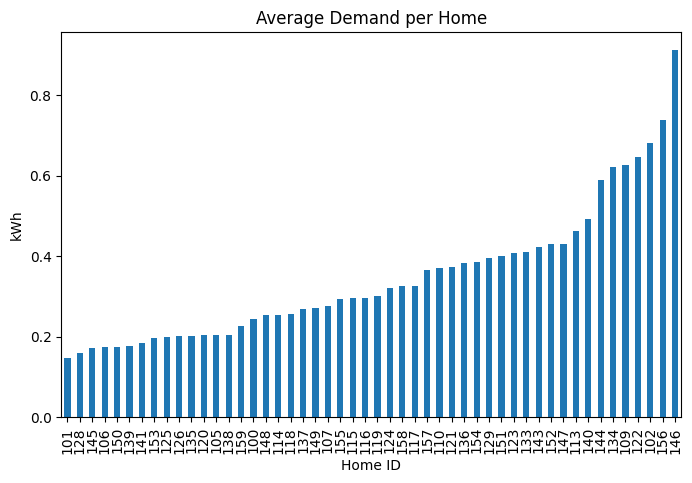

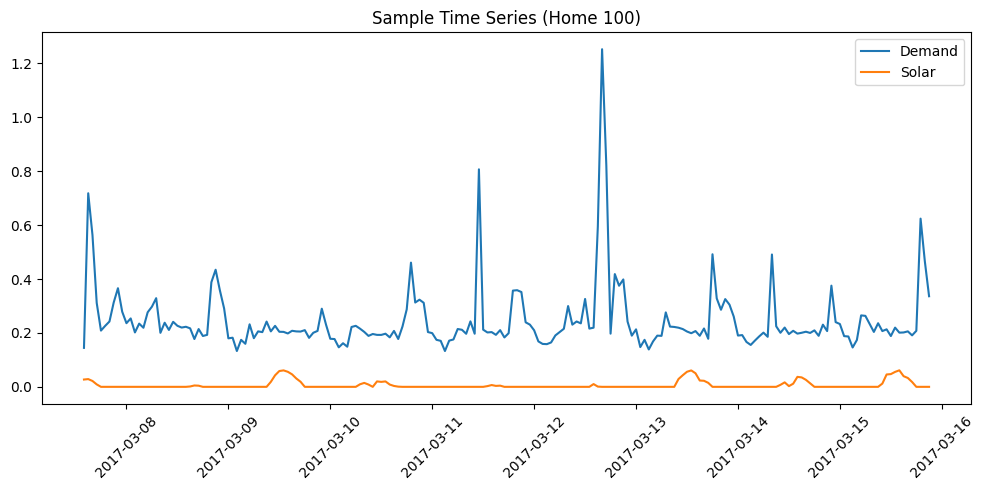


===== QUICK INSIGHTS =====
Total rows: 424616
Number of homes: 50
Mean demand: 0.342 kWh
Mean solar: 0.011 kWh
Mean price: £0.025/kWh


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("smart_home_energy_dataset.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])

print("===== BASIC INFO =====")
print(df.info())
print("\n===== SUMMARY STATS =====")
print(df.describe())

# =========================
# Missing values
# =========================
print("\n===== MISSING VALUES =====")
print(df.isna().sum())

# =========================
# Distribution plots
# =========================
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
df["demand_kwh"].hist(bins=50)
plt.title("Demand Distribution")

plt.subplot(1,3,2)
df["solar_kwh"].hist(bins=50)
plt.title("Solar Distribution")

plt.subplot(1,3,3)
df["price_kwh"].hist(bins=50)
plt.title("Price Distribution")

plt.tight_layout()
plt.show()

# =========================
# Time-based patterns
# =========================
df["hour"] = df["timestamp"].dt.hour

demand_hour = df.groupby("hour")["demand_kwh"].mean()
solar_hour = df.groupby("hour")["solar_kwh"].mean()
price_hour = df.groupby("hour")["price_kwh"].mean()

plt.figure(figsize=(8,5))
plt.plot(demand_hour, label="Demand")
plt.plot(solar_hour, label="Solar")
plt.plot(price_hour, label="Price")
plt.legend()
plt.title("Average Hourly Profiles")
plt.xlabel("Hour")
plt.ylabel("Value")
plt.grid()
plt.show()

# =========================
# Correlation
# =========================
print("\n===== CORRELATION =====")
corr = df[["demand_kwh", "solar_kwh", "price_kwh"]].corr()
print(corr)

# =========================
# Per-home variation
# =========================
home_stats = df.groupby("homeid")["demand_kwh"].mean().sort_values()

plt.figure(figsize=(8,5))
home_stats.plot(kind="bar")
plt.title("Average Demand per Home")
plt.xlabel("Home ID")
plt.ylabel("kWh")
plt.xticks(rotation=90)
plt.show()

# =========================
# Time series sample
# =========================
sample_home = df["homeid"].iloc[0]
sample = df[df["homeid"] == sample_home].iloc[:200]

plt.figure(figsize=(10,5))
plt.plot(sample["timestamp"], sample["demand_kwh"], label="Demand")
plt.plot(sample["timestamp"], sample["solar_kwh"], label="Solar")
plt.title(f"Sample Time Series (Home {sample_home})")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================
# Key insights (auto print)
# =========================
print("\n===== QUICK INSIGHTS =====")
print(f"Total rows: {len(df)}")
print(f"Number of homes: {df['homeid'].nunique()}")
print(f"Mean demand: {df['demand_kwh'].mean():.3f} kWh")
print(f"Mean solar: {df['solar_kwh'].mean():.3f} kWh")
print(f"Mean price: £{df['price_kwh'].mean():.3f}/kWh")